In [1]:
from swiftgalaxy import SWIFTGalaxy, SOAP, MaskCollection, SWIFTGalaxies
from scipy.spatial.transform import Rotation
from swiftsimio.visualisation import project_gas, project_pixel_grid
import matplotlib.patches as patches


import numpy as np, scipy, matplotlib.pyplot as plt, unyt as u, swiftsimio as sw, pandas as pd, glob, re, matplotlib.colors as mcolors

from matplotlib.lines import Line2D

In [2]:
!hostname

node17.pri.prospero.alces.network


# READ ME:

The reader is referred to Sections 3 and 4 for the code that report figures/results relied upon. The preceding sections are representative of an old pipeline which was still important to identify haloes and shows the general process. 

Section 3: Simulation box validation by comparing the two simulation boxes analysed

Section 4: Uses similar plotting functions as the whole notebook but with data that uses the correct alignment procedure of the representative haloes.


(apologies for the mess in this one)

# 1. Load and clean the slurm array data

This was also for data that was obtained in the previous pipeline with misalignment issues but it essentially shows the selection process for halo examples.

I ran a slurm job for the L025m5 box and refined the properties I retrieved. All required proprties such as gas frac, mass, corot, mmbh mass, star count etc where retrieved alongside the anisotropy parameter to streamline the analysis process and make the data cleaner

However there was a few formatting issues with the data itself, the functions below essentially remove unwanted strings and swap the format of certain data fields

In [ ]:
def clean_unyt_strings(df):
    """
    Removes '[...]' and 'dimensionless' values from all columns in the dataframe.
    """
    for col in df.columns:
        if df[col].dtype == 'object':
            # Extract only the numeric part (handles 1.23e+11, [123], etc)
            df[col] = df[col].astype(str).str.extract(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)')[0]
            # Convert to numeric, turn errors to NaN
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def load_and_combine(pattern, value_name):
    files = glob.glob(pattern)
    df_list = []

    for f in files:
        task_id = int(re.findall(r'\d+', f)[-1])
        temp_df = pd.read_csv(f)
        
        # --- CLEAN EACH SMALL DF AS IT COMES IN ---
        temp_df = clean_unyt_strings(temp_df)
        
        temp_df['task_id'] = task_id
        df_list.append(temp_df)
    
    return pd.concat(df_list, ignore_index=True)

In [5]:
df_master = load_and_combine('results/L025m5_updated/gas_density_anisotropies_*.csv', 'mass_aniso')

df_master.to_csv('L025m5_track_data.csv',index=False)

# 2. Retrieve all computed halo data at z = 0


This block essentially isolates all the data for the z = 0 snapshot. This gives a sample of present day haloes that might seem interesting to track through time

In [8]:
z0 = df_master[df_master['z'] == df_master['z'].min()]

mask = (z0['mass'] > 9e11) & (z0['mass'] < 1.1e12)

z0[mask]

,track_id,halo_index,mass_aniso,gas_frac,star_count,mmbh_mass,stellar_corot,mass,gas_count,cgm_gas_count,age_Gyr,z,a,task_id
5846,53330,61382,0.854553,0.109475,114780,5025863.5,0.590820,9.762500e+11,439420,315955,13.761125,4.440892e-16,1.0,127
5879,24596,425038,0.785441,0.096607,80468,3981590.2,0.560547,9.025000e+11,362543,289771,13.761125,4.440892e-16,1.0,127
5903,27834,1118202,1.065980,0.083699,95699,5836487.0,0.523438,9.250000e+11,319130,262784,13.761125,4.440892e-16,1.0,127
5904,6157,1129699,0.879635,0.034379,126317,19607544.0,0.507812,1.036250e+12,148898,130787,13.761125,4.440892e-16,1.0,127
5905,3289,1148626,0.812428,0.081933,119672,10032654.0,0.674805,9.487500e+11,312808,272528,13.761125,4.440892e-16,1.0,127
5907,195,1174895,0.747836,0.033149,159161,28305054.0,0.320801,9.875000e+11,136198,82801,13.761125,4.440892e-16,1.0,127


### Retrieve the most massive halo at z = 0, and obtain its full history

(1) Find the row with the largest mass at z = 0 
(2) retrieve its track id
(3) Use track id (unique halo identifier), to find halo history (find matches across all snapshots)

In [36]:
most_massive = z0[z0['mass'] == z0['mass'].max()]

target_id = most_massive['track_id'].values[0]

halo_history = df_master[df_master['track_id'] == target_id].sort_values('age_Gyr')


In [42]:
halo_history

,track_id,halo_index,mass_aniso,gas_frac,star_count,mmbh_mass,stellar_corot,mass,gas_count,cgm_gas_count,age_Gyr,z,a,task_id
1454,918,633518,0.492790,0.130847,324,2.667308e+04,0.203613,6.179688e+10,36270,19082,0.839343,6.500000e+00,0.133333,36
1918,918,642693,0.668434,0.124598,489,2.745539e+04,0.297363,7.289062e+10,40698,21407,0.860773,6.375000e+00,0.135593,37
2992,918,650945,0.806182,0.123524,1304,2.935529e+04,0.370605,9.265625e+10,51207,26067,0.883127,6.250000e+00,0.137931,38
1522,918,658973,0.850961,0.124134,1889,6.467104e+04,0.207520,1.128125e+11,62581,33291,0.906463,6.125000e+00,0.140351,39
5810,918,666583,0.685370,0.124102,2069,7.361173e+04,0.251953,1.304688e+11,72269,43512,0.930842,6.000000e+00,0.142857,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4661,918,311936,0.760886,0.054890,586969,3.570557e+08,0.270508,9.280000e+12,2109818,1813793,13.203166,4.000000e-02,0.961538,123
363,918,311724,0.760065,0.055837,586376,3.570557e+08,0.270508,9.380000e+12,2171997,1870124,13.339641,3.000000e-02,0.970874,124
4392,918,311613,0.754778,0.056812,585802,3.576660e+08,0.269531,9.450000e+12,2228609,1927982,13.478102,2.000000e-02,0.980392,125
3249,918,311348,0.747279,0.057904,586404,3.576660e+08,0.270996,9.520000e+12,2288226,1986090,13.618585,1.000000e-02,0.990099,126


### Plots of the evolution of the most massive halo

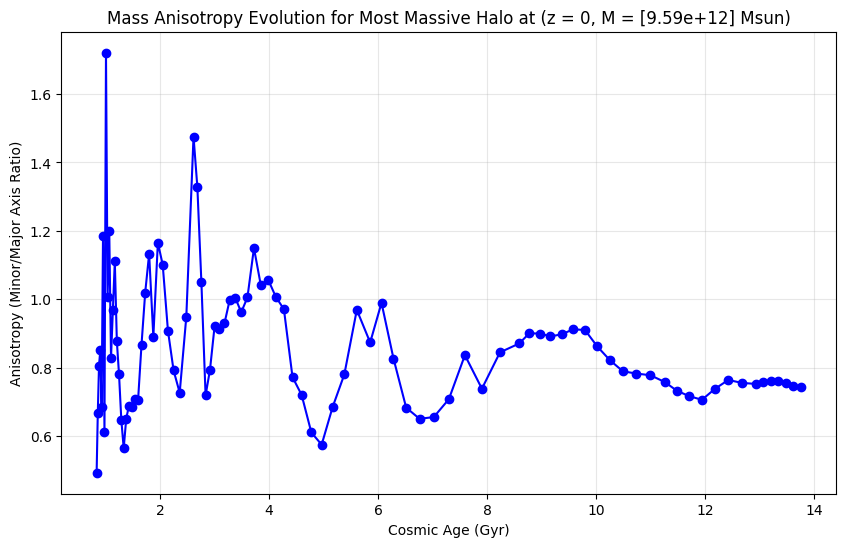

In [24]:
plt.figure(figsize=(10, 6))

# Plotting mass_aniso vs time
plt.plot(halo_history['age_Gyr'], halo_history['mass_aniso'], marker='o', linestyle='-', color='b')

# Formatting the chart
plt.title(f'Mass Anisotropy Evolution for Most Massive Halo at (z = 0, M = {most_massive["mass"].values} Msun)')
plt.xlabel('Cosmic Age (Gyr)')
plt.ylabel('Anisotropy (Minor/Major Axis Ratio)')
plt.grid(True, alpha=0.3)

plt.show()

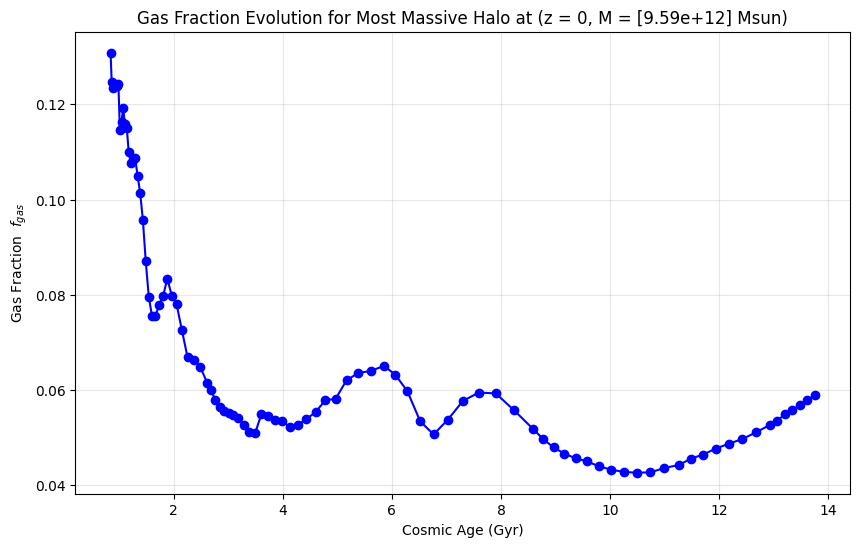

In [25]:
plt.figure(figsize=(10, 6))

# Plotting mass_aniso vs time
plt.plot(halo_history['age_Gyr'], halo_history['gas_frac'], marker='o', linestyle='-', color='b')

# Formatting the chart
plt.title(f'Gas Fraction Evolution for Most Massive Halo at (z = 0, M = {most_massive["mass"].values} Msun)')
plt.xlabel('Cosmic Age (Gyr)')
plt.ylabel(r'Gas Fraction  $f_{gas}$')
plt.grid(True, alpha=0.3)

plt.show()

### Looking at halo histories for $\approx$ 10^12 Msun haloes at z = 0

### Halo 1.

In [ ]:
candidate = z0[z0['track_id'] == 3542] #track id obtained from looking at z = 0

target_id = candidate['track_id'].values[0]

threshold_value = 1000

halo_history = df_master[df_master['track_id'] == target_id].sort_values('age_Gyr') #Retrieve the full history of the halo with specified track_id

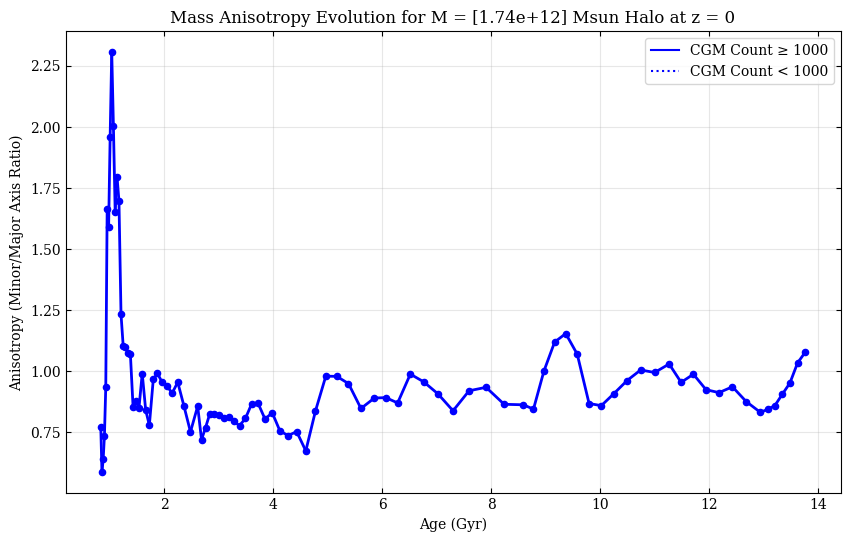

In [ ]:
plt.figure(figsize=(10, 6))


for i in range(len(halo_history) - 1):
    p1 = halo_history.iloc[i]
    p2 = halo_history.iloc[i+1]
    
    # If the count is below threshold, use dotted
    is_low_res = p2['cgm_gas_count'] < threshold_value
    ls = ':' if is_low_res else '-'
    alpha = 0.6 if is_low_res else 1.0

    plt.plot([p1['age_Gyr'], p2['age_Gyr']], 
             [p1['mass_aniso'], p2['mass_aniso']], 
             linestyle=ls, color='blue', alpha=alpha, linewidth=2)

# Add snapshots as points
plt.scatter(halo_history['age_Gyr'], halo_history['mass_aniso'], color='blue', s=20, zorder=5)
# Legend
legend_elements = [
    Line2D([0], [0], color='blue', linestyle='-', label=f'CGM Count ≥ {threshold_value}'),
    Line2D([0], [0], color='blue', linestyle=':', label=f'CGM Count < {threshold_value}')
]

plt.legend(handles=legend_elements, loc='best', frameon=True)

# formatting

plt.xlabel('Age (Gyr)')
plt.ylabel('Anisotropy (Minor/Major Axis Ratio)')
plt.title(f'Mass Anisotropy Evolution for M = {candidate["mass"].values} Msun Halo at z = 0')
plt.grid(True, alpha=0.3)

plt.show()

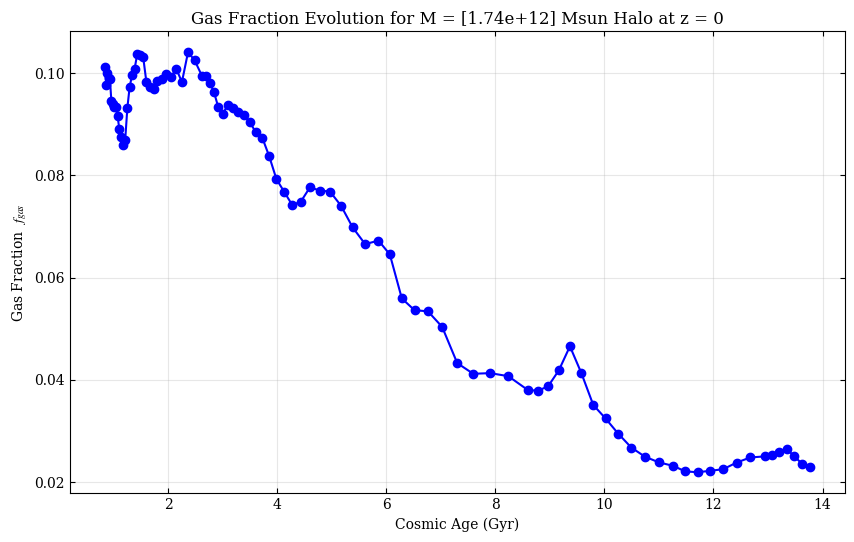

In [23]:
plt.figure(figsize=(10, 6))

# Plotting mass_aniso vs time
plt.plot(halo_history['age_Gyr'], halo_history['gas_frac'], marker='o', linestyle='-', color='b')

# Formatting the chart

plt.xlabel('Cosmic Age (Gyr)')
plt.ylabel(r'Gas Fraction  $f_{gas}$')
plt.title(f'Gas Fraction Evolution for M = {candidate["mass"].values} Msun Halo at z = 0')
plt.grid(True, alpha=0.3)

plt.show()

### Halo 2.

In [18]:
candidate = z0[z0['track_id'] == 195]

target_id = candidate['track_id'].values[0]

threshold_value = 1000

halo_history_gas_poor = df_master[df_master['track_id'] == target_id].sort_values('age_Gyr')

In [26]:
mask = (halo_history_gas_poor['task_id'] == 85) | (halo_history_gas_poor['task_id'] == 90) | (halo_history_gas_poor['task_id'] == 93) | (halo_history_gas_poor['task_id'] == 100) | (halo_history_gas_poor['task_id'] == 105) | (halo_history_gas_poor['task_id'] ==127)

halo_history_gas_poor[mask]

,track_id,halo_index,mass_aniso,gas_frac,star_count,mmbh_mass,stellar_corot,mass,gas_count,cgm_gas_count,age_Gyr,z,a,task_id
5967,195,1303971,1.087158,0.049540,157772,15506744.0,0.672852,6.450000e+11,123724,84097,4.431936,1.437500e+00,0.410256,85
2816,195,1337174,1.259653,0.025659,159855,25596618.0,0.629883,6.637500e+11,66944,49184,5.382290,1.125000e+00,0.470588,90
3084,195,1296981,2.024088,0.024412,159842,27236938.0,0.603516,6.912500e+11,68586,50598,6.064144,9.500000e-01,0.512821,93
666,195,1219563,0.609728,0.041138,159835,27351380.0,0.490723,8.612500e+11,147904,105690,7.905490,6.000000e-01,0.625000,100
1677,195,1177824,0.846677,0.038688,159265,27427674.0,0.426758,8.612500e+11,138636,100679,9.163304,4.250000e-01,0.701754,105
5907,195,1174895,0.747836,0.033149,159161,28305054.0,0.320801,9.875000e+11,136198,82801,13.761125,4.440892e-16,1.000000,127


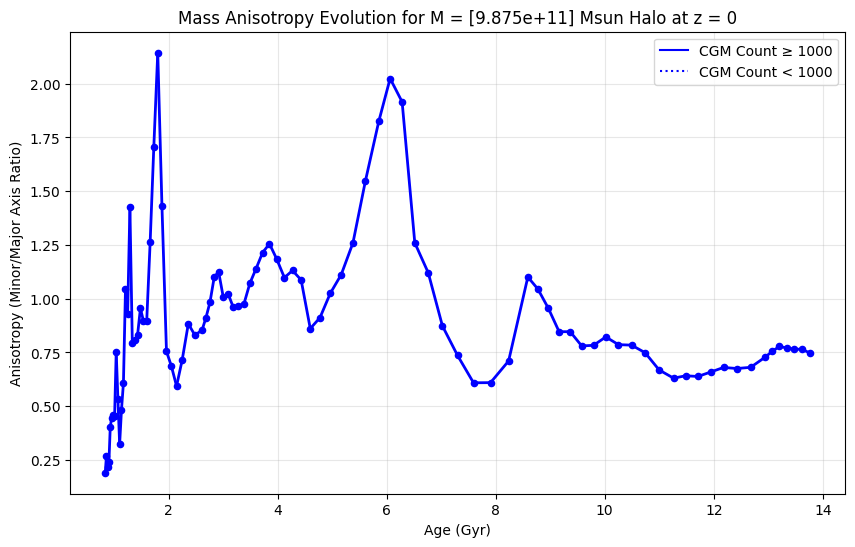

In [ ]:
plt.figure(figsize=(10, 6))


for i in range(len(halo_history) - 1):
    p1 = halo_history.iloc[i]
    p2 = halo_history.iloc[i+1]
    
    # If the count is below threshold, use dotted
    is_low_res = p2['cgm_gas_count'] < threshold_value
    ls = ':' if is_low_res else '-'
    alpha = 0.6 if is_low_res else 1.0

    plt.plot([p1['age_Gyr'], p2['age_Gyr']], 
             [p1['mass_aniso'], p2['mass_aniso']], 
             linestyle=ls, color='blue', alpha=alpha, linewidth=2)

# Add snapshots as points
plt.scatter(halo_history['age_Gyr'], halo_history['mass_aniso'], color='blue', s=20, zorder=5)

#Legend
legend_elements = [
    Line2D([0], [0], color='blue', linestyle='-', label=f'CGM Count ≥ {threshold_value}'),
    Line2D([0], [0], color='blue', linestyle=':', label=f'CGM Count < {threshold_value}')
]

plt.legend(handles=legend_elements, loc='best', frameon=True)

#formatting

plt.xlabel('Age (Gyr)')
plt.ylabel('Anisotropy (Minor/Major Axis Ratio)')
plt.title(f'Mass Anisotropy Evolution for M = {candidate["mass"].values} Msun Halo at z = 0')
plt.grid(True, alpha=0.3)

plt.show()

### Labelled Plot

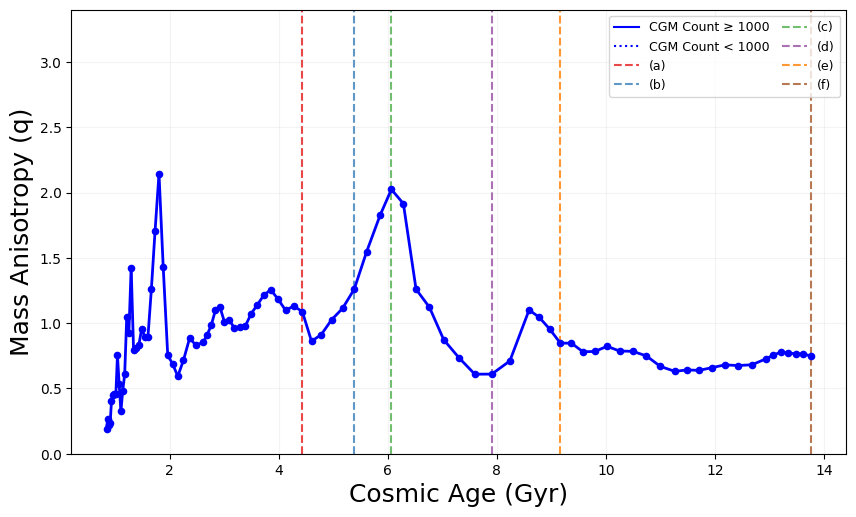

In [ ]:
# Ages for vertical lines
snapshot_ages = [4.43, 5.38, 6.06, 7.91, 9.16, 13.76]
snapshot_labels = ['a', 'b', 'c', 'd', 'e', 'f']

plt.figure(figsize=(10, 6),dpi=100)
# --- 2. Existing Plotting logic ---
for i in range(len(halo_history) - 1):
    p1 = halo_history.iloc[i]
    p2 = halo_history.iloc[i+1]
    
    is_low_res = p2['cgm_gas_count'] < threshold_value
    ls = ':' if is_low_res else '-'
    alpha = 0.6 if is_low_res else 1.0

    plt.plot([p1['age_Gyr'], p2['age_Gyr']], 
             [p1['mass_aniso'], p2['mass_aniso']], 
             linestyle=ls, color='blue', alpha=alpha, linewidth=2)

legend_elements = [
    Line2D([0], [0], color='blue', linestyle='-', label=f'CGM Count ≥ {threshold_value}'),
    Line2D([0], [0], color='blue', linestyle=':', label=f'CGM Count < {threshold_value}')
]



# Add snapshots as points
plt.scatter(halo_history['age_Gyr'], halo_history['mass_aniso'], color='blue', s=20, zorder=5)

# --- 1. Define Snapshot Colors ---
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

# Vertical Lines

snapshot_handles = []
for i, (age, label, col) in enumerate(zip(snapshot_ages, snapshot_labels, colors)):
    line = plt.axvline(x=age, color=col, linestyle='--', linewidth=1.5, alpha=0.8, 
                       label=f'({label})', zorder=1)
    snapshot_handles.append(line)
    
    


all_handles = legend_elements + snapshot_handles

# Create one unified legend
plt.legend(handles=all_handles, loc='upper right', fontsize=9, 
           frameon=True, ncol=2, columnspacing=1)


plt.xlabel('Cosmic Age (Gyr)', fontsize=18)
plt.ylabel('Mass Anisotropy (q)', fontsize=18)
plt.ylim(0, 3.4) # more room for the legend/labels

# Prevent title overlap
plt.subplots_adjust(top=0.85)


plt.grid(True, alpha=0.15)
plt.show()

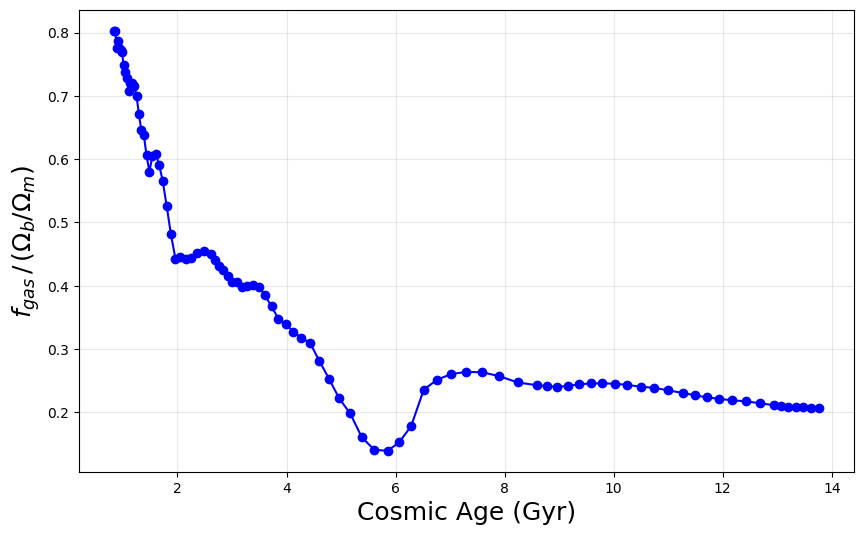

In [10]:
plt.figure(figsize=(10, 6),dpi=100)

# Plotting mass_aniso vs time
plt.plot(halo_history['age_Gyr'], halo_history['gas_frac']/0.16, marker='o', linestyle='-', color='b')

# Formatting the chart

plt.xlabel('Cosmic Age (Gyr)',fontsize=18)
plt.ylabel(r'$f_{gas} \, / \, (\Omega_{b} / \Omega_{m})$',fontsize=18)

plt.grid(True, alpha=0.3)

plt.show()

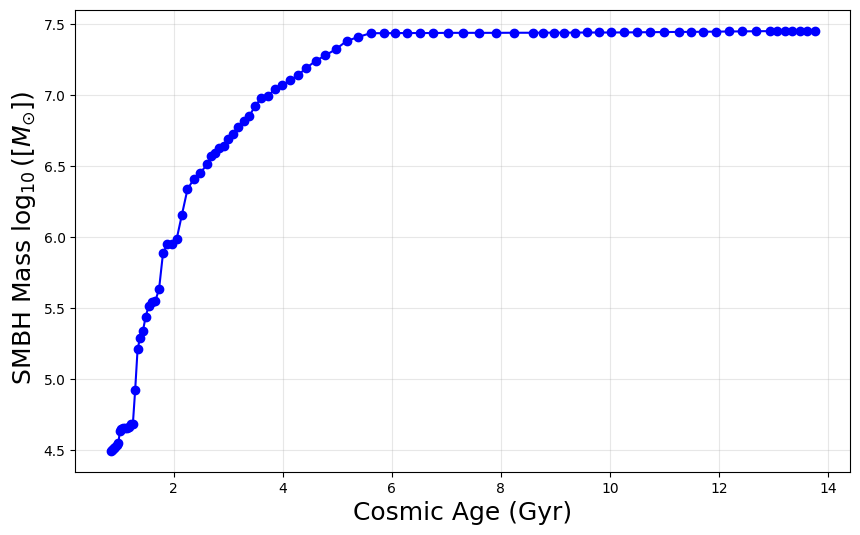

In [26]:
plt.figure(figsize=(10, 6),dpi=100)

# Plotting mass_aniso vs time
plt.plot(halo_history['age_Gyr'], np.log10(halo_history['mmbh_mass']), marker='o', linestyle='-', color='b')

# Formatting the chart

plt.xlabel('Cosmic Age (Gyr)',fontsize=18)
plt.ylabel(r' SMBH Mass $\log_{10}( [M_{\odot}])$',fontsize=18)

plt.grid(True, alpha=0.3)

plt.show()

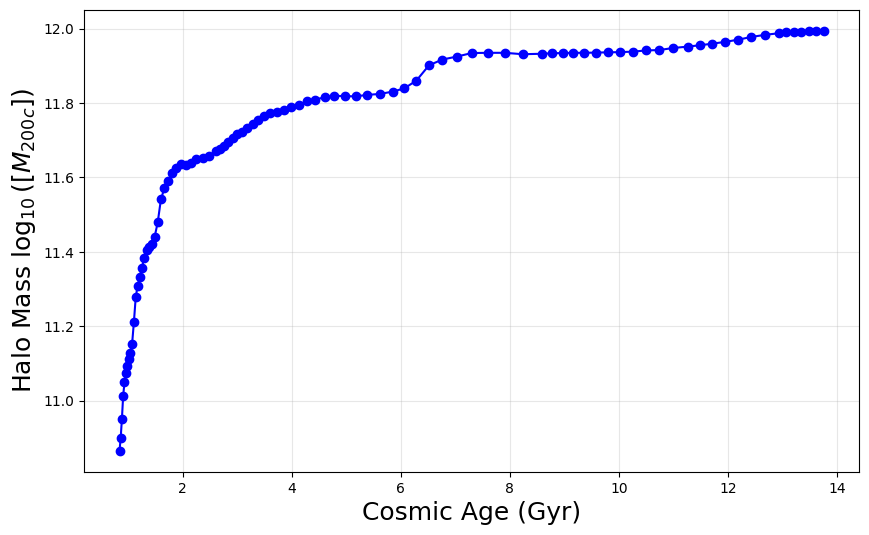

In [27]:
plt.figure(figsize=(10, 6),dpi=100)

# Plotting mass_aniso vs time
plt.plot(halo_history['age_Gyr'], np.log10(halo_history['mass']), marker='o', linestyle='-', color='b')

# Formatting the chart

plt.xlabel('Cosmic Age (Gyr)',fontsize=18)
plt.ylabel(r'Halo Mass $\log_{10}( [M_{200c}])$',fontsize=18)

plt.grid(True, alpha=0.3)

plt.show()

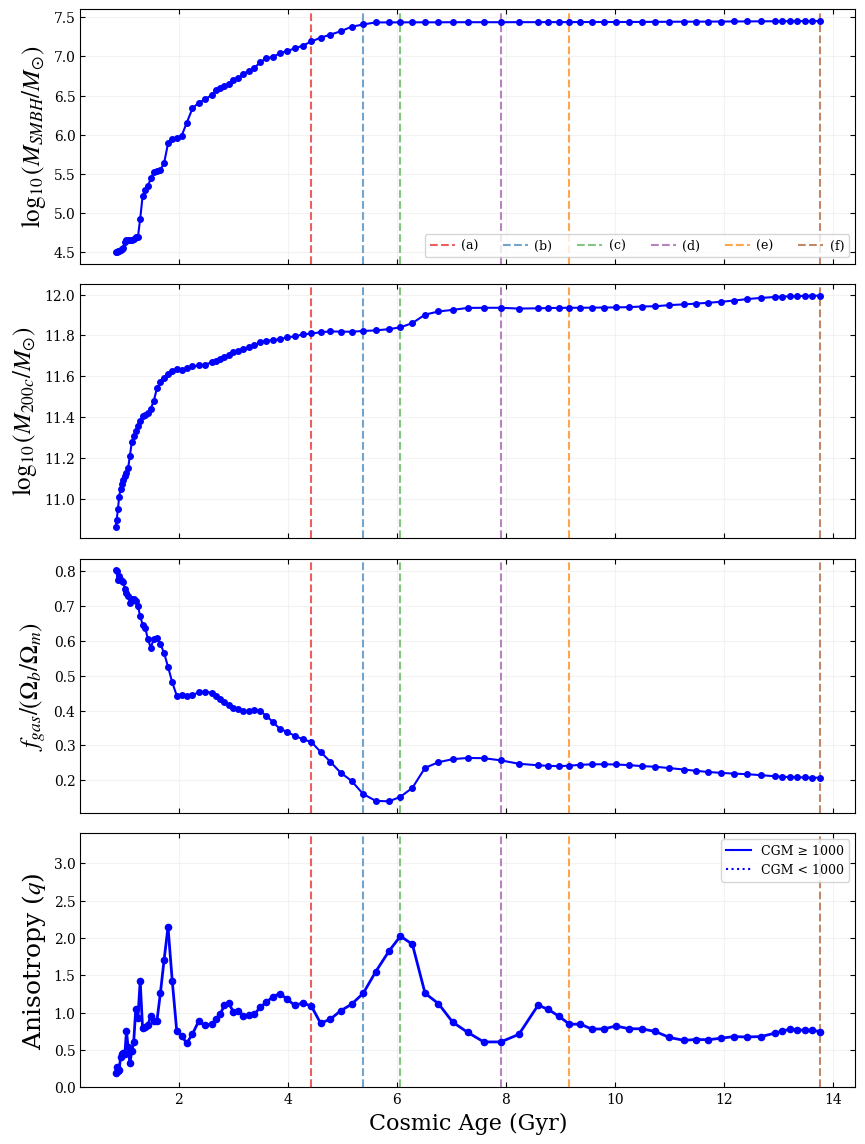

In [ ]:

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

#  figure and axes (4 rows, 1 column) ---
fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True, dpi=100)
plt.subplots_adjust(hspace=0.08) # Tighten the vertical space between panels

# Vertical lines 
snapshot_ages = [4.43, 5.38, 6.06, 7.91, 9.16, 13.76]
snapshot_labels = ['a', 'b', 'c', 'd', 'e', 'f']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

# --- Panel 0: SMBH Mass (Top) ---
ax0 = axes[0]
ax0.plot(halo_history['age_Gyr'], np.log10(halo_history['mmbh_mass']), marker='o', color='b', markersize=4)
ax0.set_ylabel(r'$\log_{10}(M_{SMBH} / M_{\odot})$', fontsize=18)

# --- Panel 1: Halo Mass ---
ax1 = axes[1]
ax1.plot(halo_history['age_Gyr'], np.log10(halo_history['mass']), marker='o', color='b', markersize=4)
ax1.set_ylabel(r'$\log_{10}(M_{200c} / M_{\odot})$', fontsize=18)

# --- Panel 2: Gas Fraction ---
ax2 = axes[2]
ax2.plot(halo_history['age_Gyr'], halo_history['gas_frac']/0.16, marker='o', color='b', markersize=4)
ax2.set_ylabel(r'$f_{gas} / (\Omega_{b}/\Omega_{m})$', fontsize=18)

# --- Panel 3: Mass Anisotropy (Bottom) ---
ax3 = axes[3]
for i in range(len(halo_history) - 1):
    p1, p2 = halo_history.iloc[i], halo_history.iloc[i+1]
    is_low_res = p2['cgm_gas_count'] < threshold_value
    ls, alpha = (':', 0.6) if is_low_res else ('-', 1.0)
    ax3.plot([p1['age_Gyr'], p2['age_Gyr']], [p1['mass_aniso'], p2['mass_aniso']], 
             linestyle=ls, color='blue', alpha=alpha, linewidth=2)

ax3.scatter(halo_history['age_Gyr'], halo_history['mass_aniso'], color='blue', s=20, zorder=5)
ax3.set_ylabel('Anisotropy ($q$)', fontsize=18)
ax3.set_xlabel('Cosmic Age (Gyr)', fontsize=16)
ax3.set_ylim(0, 3.4)

# Legend for the Anisotropy line types
cgm_legends = [
    Line2D([0], [0], color='blue', linestyle='-', label=f'CGM ≥ {threshold_value}'),
    Line2D([0], [0], color='blue', linestyle=':', label=f'CGM < {threshold_value}')
]
ax3.legend(handles=cgm_legends, loc='upper right', fontsize=9, frameon=True)

# --- Add Vertical Snapshot Lines to All Panels ---
snapshot_handles = []
for ax in axes:
    ax.grid(True, alpha=0.15)
    for age, col in zip(snapshot_ages, colors):
        line = ax.axvline(x=age, color=col, linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
        if ax == axes[0]: # Collect handles from the first axis for the legend
            snapshot_handles.append(line)

# Add the Snapshot legend to the very top panel
ax0.legend(handles=snapshot_handles, labels=[f'({l})' for l in snapshot_labels], 
           loc='lower right', ncol=6, fontsize=9, frameon=True, handletextpad=0.5)

plt.show()

/users/aritbick/jupyter_project/swift-env/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


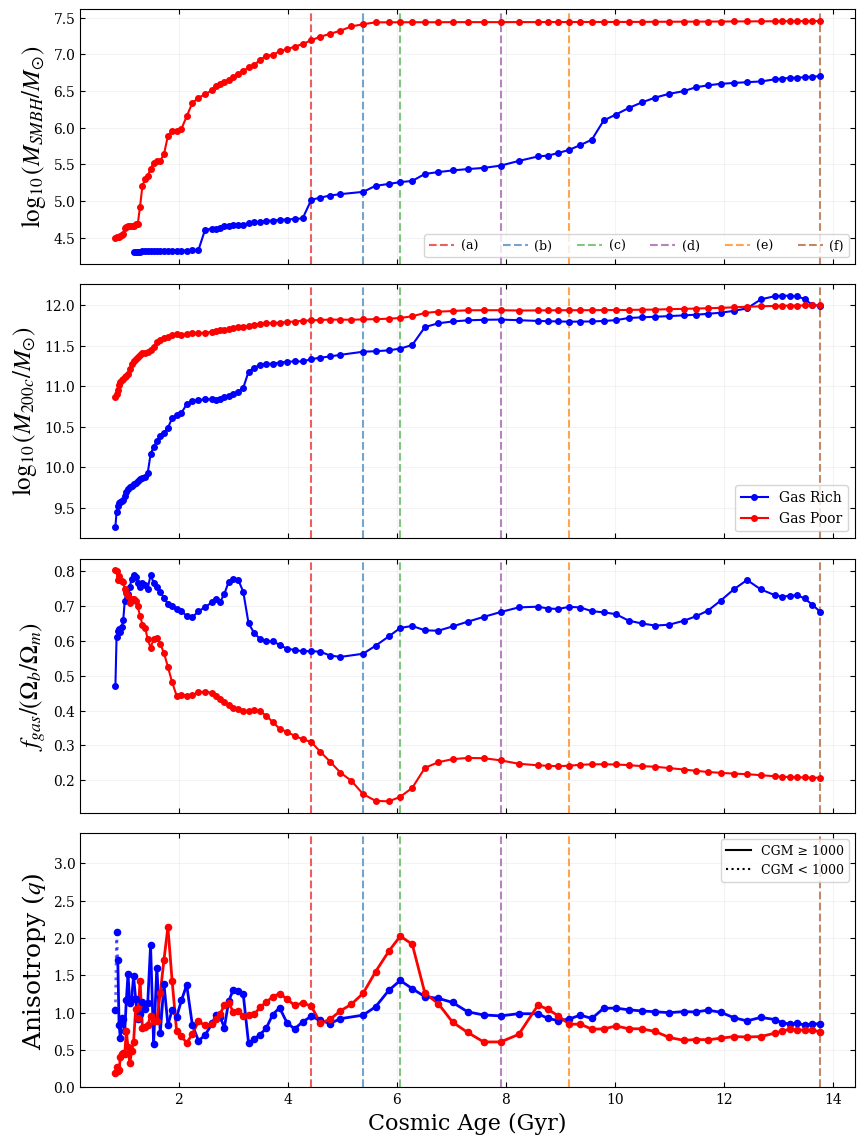

In [ ]:

threshold_value = 1000
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True


fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True, dpi=100)
plt.subplots_adjust(hspace=0.08) 


snapshot_ages = [4.43, 5.38, 6.06, 7.91, 9.16, 13.76]
snapshot_labels = ['a', 'b', 'c', 'd', 'e', 'f']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']


datasets = [
    ('Gas Rich', halo_history_gas_rich, 'blue'),
    ('Gas Poor', halo_history_gas_poor, 'red')
]

ax0, ax1, ax2, ax3 = axes


for label, df, color in datasets:
    # Panel 0: SMBH Mass
    ax0.plot(df['age_Gyr'], np.log10(df['mmbh_mass']), marker='o', color=color, markersize=4)
    
    # Panel 1: Halo Mass (Adding label here for the dataset legend)
    ax1.plot(df['age_Gyr'], np.log10(df['mass']), marker='o', color=color, markersize=4, label=label)
    
    # Panel 2: Gas Fraction
    ax2.plot(df['age_Gyr'], df['gas_frac']/0.16, marker='o', color=color, markersize=4)

ax0.set_ylabel(r'$\log_{10}(M_{SMBH} / M_{\odot})$', fontsize=18)
ax1.set_ylabel(r'$\log_{10}(M_{200c} / M_{\odot})$', fontsize=18)
ax2.set_ylabel(r'$f_{gas} / (\Omega_{b}/\Omega_{m})$', fontsize=18)

# Add dataset legend to Panel 1
ax1.legend(loc='lower right', fontsize=10, frameon=True)

#  Mass Anisotropy 
for label, df, color in datasets:
    # Plot line segments based on threshold
    for i in range(len(df) - 1):
        p1, p2 = df.iloc[i], df.iloc[i+1]
        is_low_res = p2['cgm_gas_count'] < threshold_value
        ls, alpha = (':', 0.6) if is_low_res else ('-', 1.0)
        ax3.plot([p1['age_Gyr'], p2['age_Gyr']], [p1['mass_aniso'], p2['mass_aniso']], 
                 linestyle=ls, color=color, alpha=alpha, linewidth=2)

    # Plot scatter points on top
    ax3.scatter(df['age_Gyr'], df['mass_aniso'], color=color, s=20, zorder=5)

ax3.set_ylabel('Anisotropy ($q$)', fontsize=18)
ax3.set_xlabel('Cosmic Age (Gyr)', fontsize=16)
ax3.set_ylim(0, 3.4)

# Legend for the Anisotropy line types 
cgm_legends = [
    Line2D([0], [0], color='black', linestyle='-', label=f'CGM ≥ {threshold_value}'),
    Line2D([0], [0], color='black', linestyle=':', label=f'CGM < {threshold_value}')
]
ax3.legend(handles=cgm_legends, loc='upper right', fontsize=9, frameon=True)

# 
snapshot_handles = []
for ax in axes:
    ax.grid(True, alpha=0.15)
    for age, col in zip(snapshot_ages, colors):
        line = ax.axvline(x=age, color=col, linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
        if ax == ax0: # Collect handles from the first axis for the legend
            snapshot_handles.append(line)

# Add the Snapshot legend to the very top panel
ax0.legend(handles=snapshot_handles, labels=[f'({l})' for l in snapshot_labels], 
           loc='lower right', ncol=6, fontsize=9, frameon=True, handletextpad=0.5)

plt.show()

## Secondary Example Halo


In [19]:
target_id = 53330
threshold_value = 300
candidate = z0[z0['track_id'] == target_id]
halo_history_gas_rich = df_master[df_master['track_id'] == target_id].sort_values('age_Gyr')


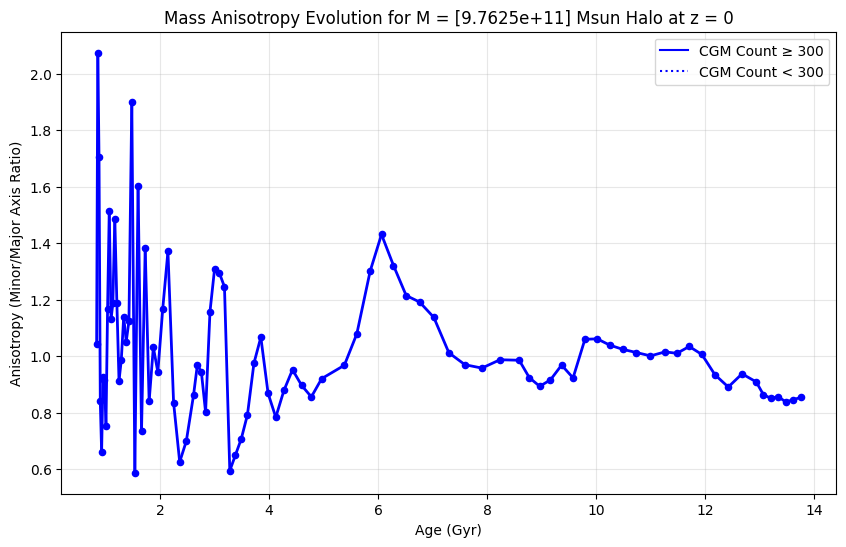

In [ ]:
plt.figure(figsize=(10, 6))


for i in range(len(halo_history) - 1):
    p1 = halo_history.iloc[i]
    p2 = halo_history.iloc[i+1]
    
    # If the count is below threshold, use dotted
    is_low_res = p2['cgm_gas_count'] < threshold_value
    ls = ':' if is_low_res else '-'
    alpha = 0.6 if is_low_res else 1.0

    plt.plot([p1['age_Gyr'], p2['age_Gyr']], 
             [p1['mass_aniso'], p2['mass_aniso']], 
             linestyle=ls, color='blue', alpha=alpha, linewidth=2)

# Add snapshots as points
plt.scatter(halo_history['age_Gyr'], halo_history['mass_aniso'], color='blue', s=20, zorder=5)


legend_elements = [
    Line2D([0], [0], color='blue', linestyle='-', label=f'CGM Count ≥ {threshold_value}'),
    Line2D([0], [0], color='blue', linestyle=':', label=f'CGM Count < {threshold_value}')
]

plt.legend(handles=legend_elements, loc='best', frameon=True)



plt.xlabel('Age (Gyr)')
plt.ylabel('Anisotropy (Minor/Major Axis Ratio)')
plt.title(f'Mass Anisotropy Evolution for M = {candidate["mass"].values} Msun Halo at z = 0')
plt.grid(True, alpha=0.3)

plt.show()

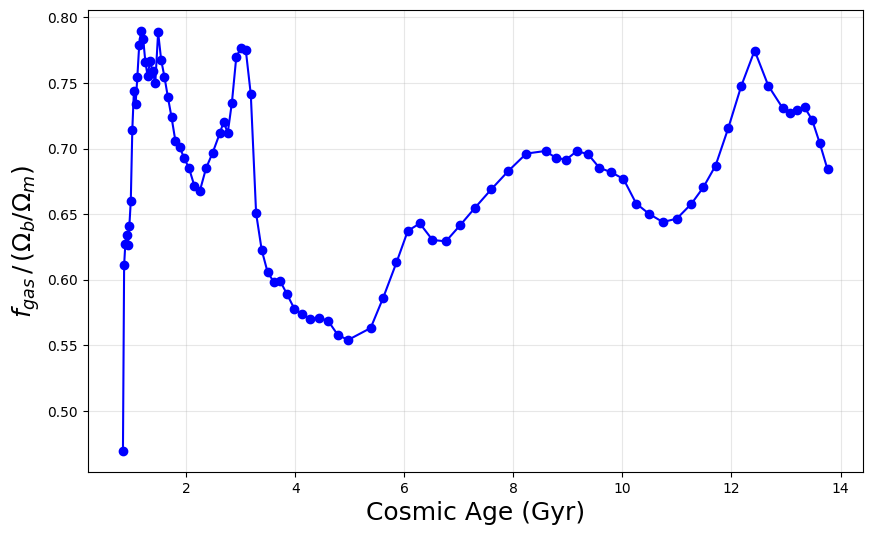

In [14]:
plt.figure(figsize=(10, 6),dpi=100)

# Plotting mass_aniso vs time
plt.plot(halo_history['age_Gyr'], halo_history['gas_frac']/0.16, marker='o', linestyle='-', color='b')

# Formatting the chart

plt.xlabel('Cosmic Age (Gyr)',fontsize=18)
plt.ylabel(r'$f_{gas} \, / \, (\Omega_{b} / \Omega_{m})$',fontsize=18)

plt.grid(True, alpha=0.3)

plt.show()

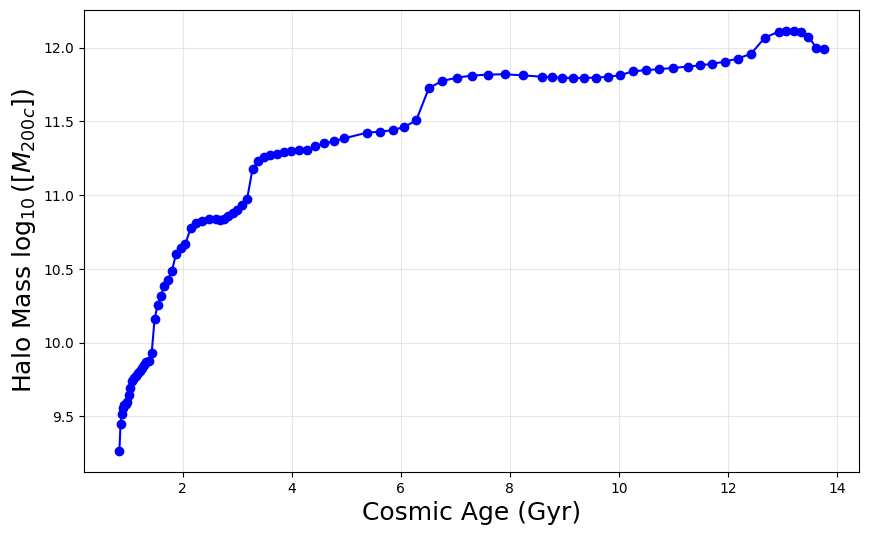

In [16]:
plt.figure(figsize=(10, 6),dpi=100)

# Plotting mass_aniso vs time
plt.plot(halo_history['age_Gyr'], np.log10(halo_history['mass']), marker='o', linestyle='-', color='b')

# Formatting the chart

plt.xlabel('Cosmic Age (Gyr)',fontsize=18)
plt.ylabel(r'Halo Mass $\log_{10}( [M_{200c}])$',fontsize=18)

plt.grid(True, alpha=0.3)

plt.show()

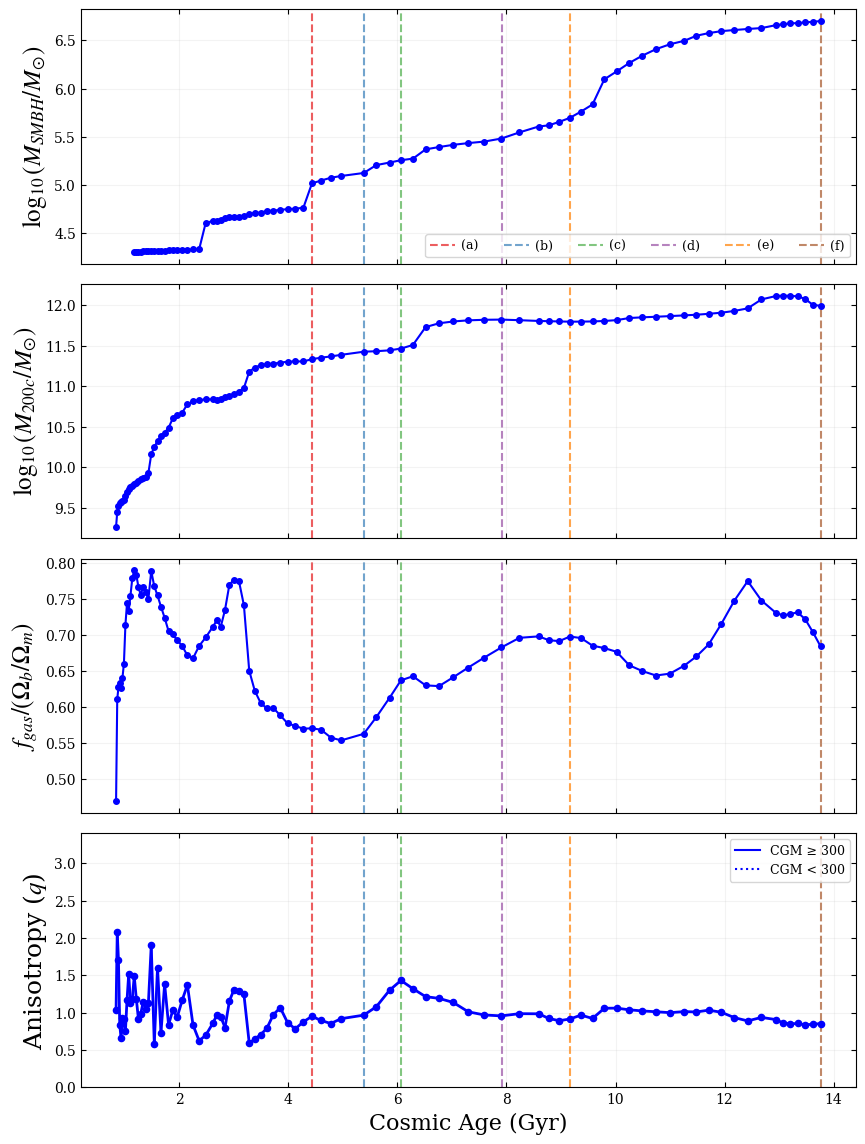

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True, dpi=100)
plt.subplots_adjust(hspace=0.08) 


snapshot_ages = [4.43, 5.38, 6.06, 7.91, 9.16, 13.76]
snapshot_labels = ['a', 'b', 'c', 'd', 'e', 'f']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']


ax0 = axes[0]
ax0.plot(halo_history['age_Gyr'], np.log10(halo_history['mmbh_mass']), marker='o', color='b', markersize=4)
ax0.set_ylabel(r'$\log_{10}(M_{SMBH} / M_{\odot})$', fontsize=18)


ax1 = axes[1]
ax1.plot(halo_history['age_Gyr'], np.log10(halo_history['mass']), marker='o', color='b', markersize=4)
ax1.set_ylabel(r'$\log_{10}(M_{200c} / M_{\odot})$', fontsize=18)


ax2 = axes[2]
ax2.plot(halo_history['age_Gyr'], halo_history['gas_frac']/0.16, marker='o', color='b', markersize=4)
ax2.set_ylabel(r'$f_{gas} / (\Omega_{b}/\Omega_{m})$', fontsize=18)


ax3 = axes[3]
for i in range(len(halo_history) - 1):
    p1, p2 = halo_history.iloc[i], halo_history.iloc[i+1]
    is_low_res = p2['cgm_gas_count'] < threshold_value
    ls, alpha = (':', 0.6) if is_low_res else ('-', 1.0)
    ax3.plot([p1['age_Gyr'], p2['age_Gyr']], [p1['mass_aniso'], p2['mass_aniso']], 
             linestyle=ls, color='blue', alpha=alpha, linewidth=2)

ax3.scatter(halo_history['age_Gyr'], halo_history['mass_aniso'], color='blue', s=20, zorder=5)
ax3.set_ylabel('Anisotropy ($q$)', fontsize=18)
ax3.set_xlabel('Cosmic Age (Gyr)', fontsize=16)
ax3.set_ylim(0, 3.4)


cgm_legends = [
    Line2D([0], [0], color='blue', linestyle='-', label=f'CGM ≥ {threshold_value}'),
    Line2D([0], [0], color='blue', linestyle=':', label=f'CGM < {threshold_value}')
]
ax3.legend(handles=cgm_legends, loc='upper right', fontsize=9, frameon=True)


snapshot_handles = []
for ax in axes:
    ax.grid(True, alpha=0.15)
    for age, col in zip(snapshot_ages, colors):
        line = ax.axvline(x=age, color=col, linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
        if ax == axes[0]: 
            snapshot_handles.append(line)


ax0.legend(handles=snapshot_handles, labels=[f'({l})' for l in snapshot_labels], 
           loc='lower right', ncol=6, fontsize=9, frameon=True, handletextpad=0.5)

plt.show()

### Halo 3.

In [16]:
candidate = z0[z0['track_id'] == 2923]

target_id = candidate['track_id'].values[0]

threshold_value = 1000

halo_history = df_master[df_master['track_id'] == target_id].sort_values('age_Gyr')

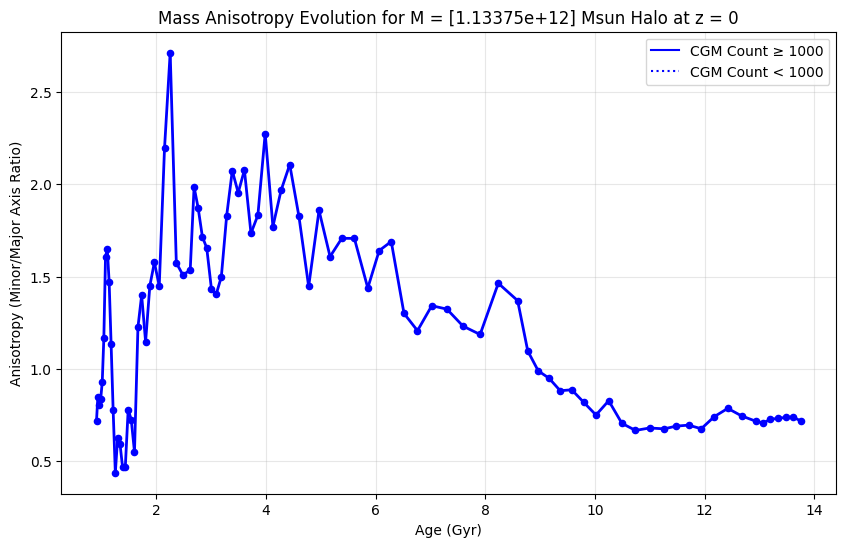

In [ ]:
plt.figure(figsize=(10, 6))


for i in range(len(halo_history) - 1):
    p1 = halo_history.iloc[i]
    p2 = halo_history.iloc[i+1]
    
    # If the count is below threshold, use dotted
    is_low_res = p2['cgm_gas_count'] < threshold_value
    ls = ':' if is_low_res else '-'
    alpha = 0.6 if is_low_res else 1.0

    plt.plot([p1['age_Gyr'], p2['age_Gyr']], 
             [p1['mass_aniso'], p2['mass_aniso']], 
             linestyle=ls, color='blue', alpha=alpha, linewidth=2)

# Add snapshots as points
plt.scatter(halo_history['age_Gyr'], halo_history['mass_aniso'], color='blue', s=20, zorder=5)


legend_elements = [
    Line2D([0], [0], color='blue', linestyle='-', label=f'CGM Count ≥ {threshold_value}'),
    Line2D([0], [0], color='blue', linestyle=':', label=f'CGM Count < {threshold_value}')
]

plt.legend(handles=legend_elements, loc='best', frameon=True)



plt.xlabel('Age (Gyr)')
plt.ylabel('Anisotropy (Minor/Major Axis Ratio)')
plt.title(f'Mass Anisotropy Evolution for M = {candidate["mass"].values} Msun Halo at z = 0')
plt.grid(True, alpha=0.3)

plt.show()

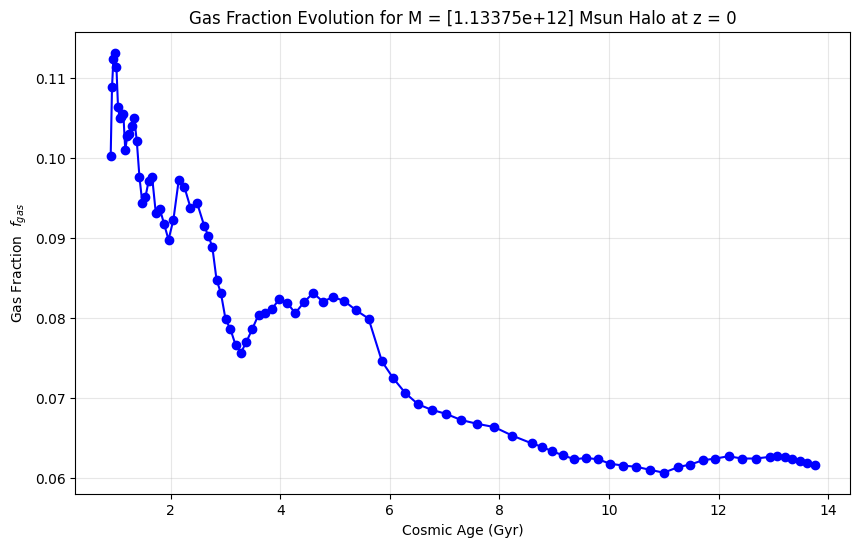

In [18]:
plt.figure(figsize=(10, 6))

# Plotting mass_aniso vs time
plt.plot(halo_history['age_Gyr'], halo_history['gas_frac'], marker='o', linestyle='-', color='b')

# Formatting the chart

plt.xlabel('Cosmic Age (Gyr)')
plt.ylabel(r'Gas Fraction  $f_{gas}$')
plt.title(f'Gas Fraction Evolution for M = {candidate["mass"].values} Msun Halo at z = 0')
plt.grid(True, alpha=0.3)

plt.show()

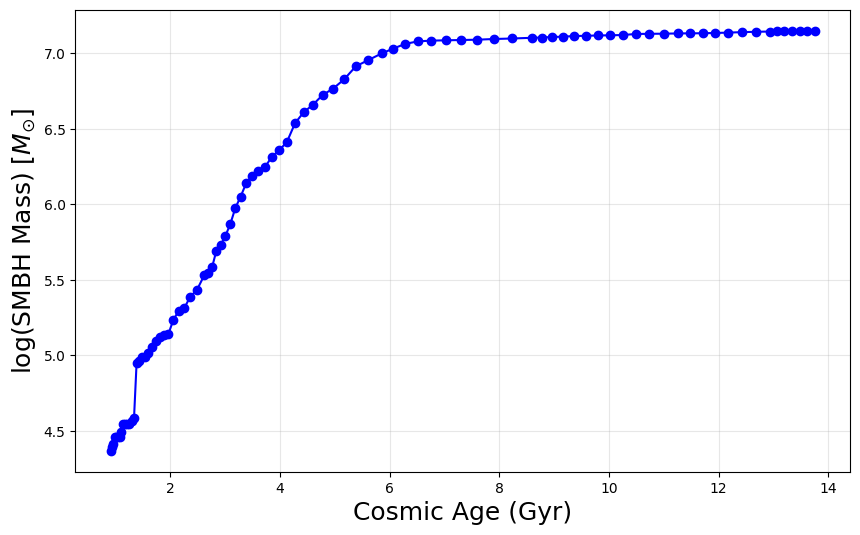

In [19]:
plt.figure(figsize=(10, 6),dpi=100)

# Plotting mass_aniso vs time
plt.plot(halo_history['age_Gyr'], np.log10(halo_history['mmbh_mass']), marker='o', linestyle='-', color='b')

# Formatting the chart

plt.xlabel('Cosmic Age (Gyr)',fontsize=18)
plt.ylabel(r'log(SMBH Mass) [$M_{\odot}$]',fontsize=18)

plt.grid(True, alpha=0.3)

plt.show()

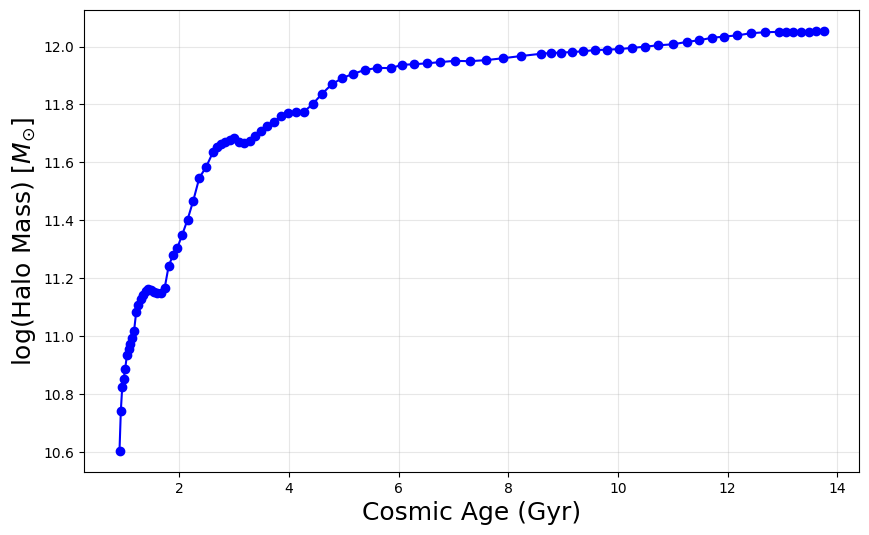

In [20]:
plt.figure(figsize=(10, 6),dpi=100)

# Plotting mass_aniso vs time
plt.plot(halo_history['age_Gyr'], np.log10(halo_history['mass']), marker='o', linestyle='-', color='b')

# Formatting the chart

plt.xlabel('Cosmic Age (Gyr)',fontsize=18)
plt.ylabel(r'log(Halo Mass) [$M_{\odot}$]',fontsize=18)

plt.grid(True, alpha=0.3)

plt.show()

### Halo 4

In [6]:
mask = (z0['mass'] > 5e11 ) & (z0['mass']< 1e12)
z0[mask]

,track_id,halo_index,mass_aniso,gas_frac,star_count,mmbh_mass,stellar_corot,mass,gas_count,cgm_gas_count,age_Gyr,z,a,task_id
5842,200007,489,0.904526,0.110663,55063,2346038.8,0.652344,5.231250e+11,237357,139262,13.761125,4.440892e-16,1.0,127
5843,2284,12730,0.699579,0.067347,101685,7896423.5,0.717773,6.043750e+11,160224,119118,13.761125,4.440892e-16,1.0,127
5846,53330,61382,0.854553,0.109475,114780,5025863.5,0.590820,9.762500e+11,439420,315955,13.761125,4.440892e-16,1.0,127
5847,1,72474,1.239836,0.054995,79552,7505417.0,0.675781,5.725000e+11,125205,95232,13.761125,4.440892e-16,1.0,127
5851,11746,124142,1.260475,0.029793,84159,9336472.0,0.673828,6.031250e+11,74067,59209,13.761125,4.440892e-16,1.0,127
5854,5882,194878,1.068701,0.055986,107872,15411377.0,0.457031,8.275000e+11,190266,162750,13.761125,4.440892e-16,1.0,127
5855,47191,196785,0.920858,0.109047,91344,4920959.5,0.534180,7.150000e+11,313280,240442,13.761125,4.440892e-16,1.0,127
5856,25067,198294,0.859089,0.123346,30387,729560.9,0.549805,5.668750e+11,295890,201313,13.761125,4.440892e-16,1.0,127
5859,2556,209209,1.033148,0.089623,69456,2608299.2,0.670898,5.300000e+11,192478,129642,13.761125,4.440892e-16,1.0,127
5862,107605,244565,0.929831,0.058168,99587,3652572.8,0.615234,5.681250e+11,125232,86783,13.761125,4.440892e-16,1.0,127


In [33]:


candidate = z0[z0['track_id'] == 53330]

target_id = candidate['track_id'].values[0]

threshold_value = 1000

halo_history = df_master[df_master['track_id'] == target_id].sort_values('age_Gyr')

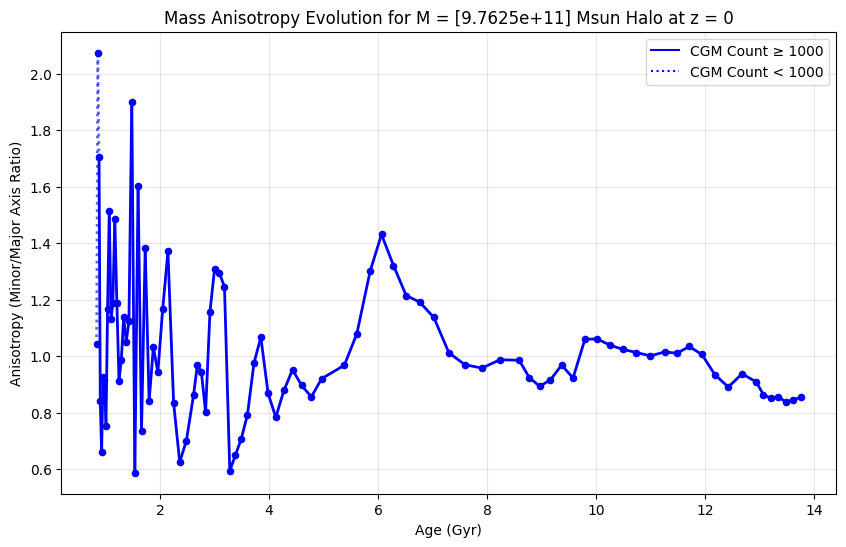

In [ ]:
plt.figure(figsize=(10, 6))


for i in range(len(halo_history) - 1):
    p1 = halo_history.iloc[i]
    p2 = halo_history.iloc[i+1]
    
    
    is_low_res = p2['cgm_gas_count'] < threshold_value
    ls = ':' if is_low_res else '-'
    alpha = 0.6 if is_low_res else 1.0

    plt.plot([p1['age_Gyr'], p2['age_Gyr']], 
             [p1['mass_aniso'], p2['mass_aniso']], 
             linestyle=ls, color='blue', alpha=alpha, linewidth=2)


plt.scatter(halo_history['age_Gyr'], halo_history['mass_aniso'], color='blue', s=20, zorder=5)

legend_elements = [
    Line2D([0], [0], color='blue', linestyle='-', label=f'CGM Count ≥ {threshold_value}'),
    Line2D([0], [0], color='blue', linestyle=':', label=f'CGM Count < {threshold_value}')
]

plt.legend(handles=legend_elements, loc='best', frameon=True)


plt.xlabel('Age (Gyr)')
plt.ylabel('Anisotropy (Minor/Major Axis Ratio)')
plt.title(f'Mass Anisotropy Evolution for M = {candidate["mass"].values} Msun Halo at z = 0')
plt.grid(True, alpha=0.3)

plt.show()

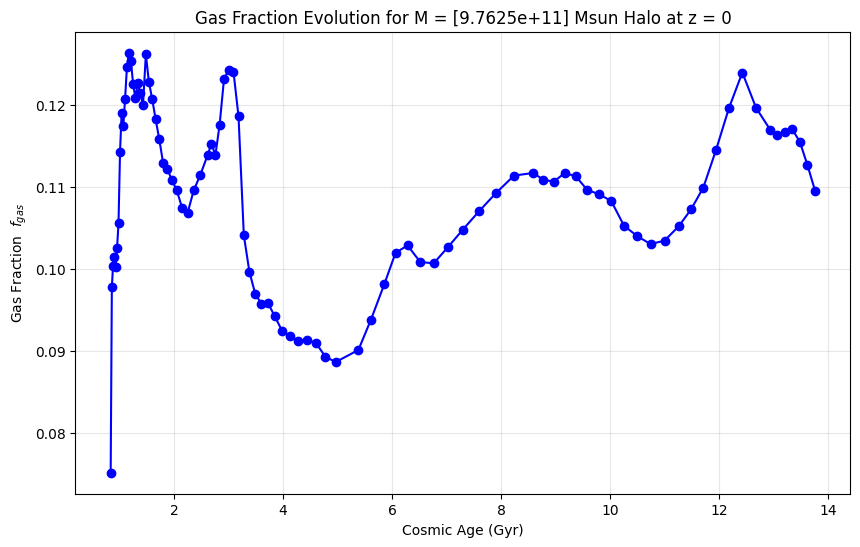

In [35]:
plt.figure(figsize=(10, 6))

# Plotting mass_aniso vs time
plt.plot(halo_history['age_Gyr'], halo_history['gas_frac'], marker='o', linestyle='-', color='b')

# Formatting the chart

plt.xlabel('Cosmic Age (Gyr)')
plt.ylabel(r'Gas Fraction  $f_{gas}$')
plt.title(f'Gas Fraction Evolution for M = {candidate["mass"].values} Msun Halo at z = 0')
plt.grid(True, alpha=0.3)

plt.show()

### Median Gas Frac vs Halo Mass Trends for L025m5

In [10]:
print(z0)

      track_id  halo_index  mass_aniso  gas_frac  star_count    mmbh_mass  \
5842    200007         489    0.904526  0.110663       55063   2346038.80   
5843      2284       12730    0.699579  0.067347      101685   7896423.50   
5844      3299       30305    0.851795  0.085117       32293    597834.56   
5845      3542       53542    1.078817  0.022989      283582  68359380.00   
5846     53330       61382    0.854553  0.109475      114780   5025863.50   
...        ...         ...         ...       ...         ...          ...   
5905      3289     1148626    0.812428  0.081933      119672  10032654.00   
5906      1453     1167925    1.034042  0.073001       51913   1347065.00   
5907       195     1174895    0.747836  0.033149      159161  28305054.00   
5908      8245     1179986    0.872289  0.107735       44288    705719.00   
5909     53639     1191313    1.037804  0.101179       49439   1103878.00   

      stellar_corot          mass  gas_count  cgm_gas_count    age_Gyr  \
5

## 3. Load in L200m6 data for a convergence test plot


This section is to form a comparison between the L025m5 and L200m6 simulation boxes that is present in the appendix of the paper. 

You'll notice that this still uses the data from the old analysis, this is okay since it only makes use of the masses and gas fractions of the haloes which remain regardless of pipeline and orientation. It would be different if the comparison used spatial anisotropy parameters!

In [20]:
# 1. Get a list of all result files
files = glob.glob('results/L200m6/gas_density_anisotropies_*.csv')

# 2. Read each file into a list and combine
df_final = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# 3. Check if we hit the target of 3809 halos
print(f"Total files found: {len(files)}")
print(f"Total halos in merged data: {len(df_final)}")

df_orig = pd.read_csv('results/halo_properties_L200m6.csv')

df_combined = pd.merge(df_orig, df_final, on='halo_index',how='left')

df_combined = df_combined[df_combined['mass_aniso'] < 4.0] ## Remove outliers

files = glob.glob('results/L200m6/zeros_check_*.csv')

# 2. Read each file into a list and combine
df_final_zeros = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df_combined = pd.merge(df_combined, df_final_zeros, on='halo_index',how='left')

Total files found: 126
Total halos in merged data: 30128


In [24]:
df_combined

df_small = z0
df_large = df_combined

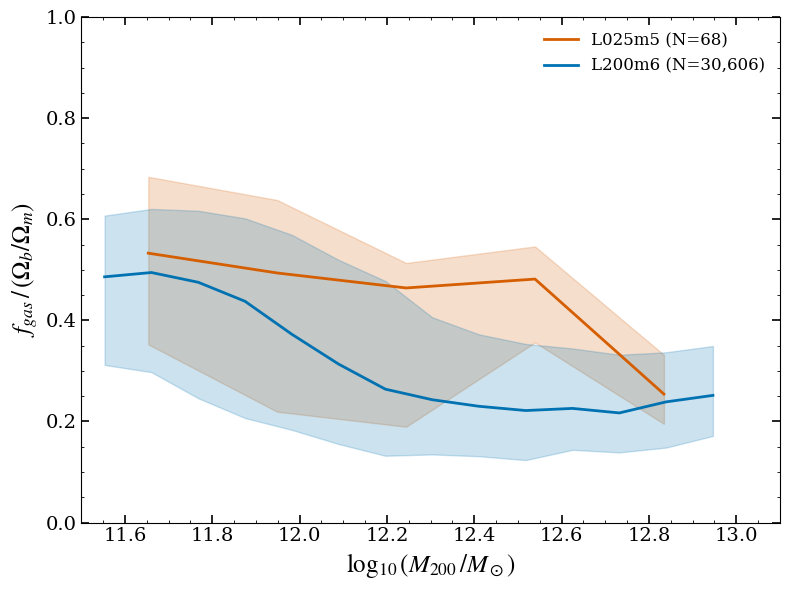

In [ ]:
def get_binned_stats(mass, gas_frac, n_bins=10):
    """Helper to calculate median and 16/84 percentiles"""
    log_m = np.log10(mass)
    f_norm = gas_frac / 0.16
    
    bins = np.linspace(log_m.min(), log_m.max(), n_bins)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    med = binned_statistic(log_m, f_norm, statistic='median', bins=bins).statistic
    p16 = binned_statistic(log_m, f_norm, statistic=lambda x: np.percentile(x, 16), bins=bins).statistic
    p84 = binned_statistic(log_m, f_norm, statistic=lambda x: np.percentile(x, 84), bins=bins).statistic
    
    return bin_centers, med, p16, p84


# Small dataset (60 entries) - Fewer bins to keep it smooth
centers_small, med_small, p16_small, p84_small = get_binned_stats(df_small['mass'], df_small['gas_frac'], n_bins=6)

# Large dataset (30,000 entries) - More bins allowed due to high N
centers_large, med_large, p16_large, p84_large = get_binned_stats(df_large['mass'], df_large['gas_frac'], n_bins=15)


fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# Dataset 
ax.fill_between(centers_small, p16_small, p84_small, color='#D55E00', alpha=0.2)
ax.plot(centers_small, med_small, color='#D55E00', lw=2, label='L025m5 (N=68)')

# Dataset 2 
ax.fill_between(centers_large, p16_large, p84_large, color='#0072B2', alpha=0.2)
ax.plot(centers_large, med_large, color='#0072B2', lw=2, label='L200m6 (N=30,606)')

# Axis Formatting
ax.set_xlabel(r'$\log_{10}(M_{200} \, /M_\odot)$', fontsize=18)
ax.set_ylabel(r'$f_{gas} \, / \, (\Omega_{b} / \Omega_{m})$', fontsize=18)
ax.set_ylim(0, 1.0)

ax.set_xlim(11.5, 13.1) # Adjust based on your mass range

ax.tick_params(axis='both', which='major', labelsize=14, length=6, width=1.2)
ax.minorticks_on()
ax.legend(frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

## 4. The correct results for the two example haloes

An issue was found with the previous evolutionary tracks where there was misalignment due to merger events in the history's of each halo

This new data is based on newly ran code that redefined the rotational alignment procedure and re-analysed the temporal anisotorpy evolution for the two example haloes 

In [28]:
df_master = load_and_combine('results/L025m5_updated/example_haloes_gas_density_anisotropies_*.csv', 'mass_aniso')

df_master.to_csv('L025m5_track_data.csv',index=False)

In [29]:
z0 = df_master[df_master['z'] == df_master['z'].min()]

In [ ]:
target_id = 53330 # Gas rich halo from before
threshold_value = 300
candidate = z0[z0['track_id'] == target_id]
halo_history_gas_rich = df_master[df_master['track_id'] == target_id].sort_values('age_Gyr')

target_id = 195 # Gas poor halo from before

candidate = z0[z0['track_id'] == target_id]
halo_history_gas_poor = df_master[df_master['track_id'] == target_id].sort_values('age_Gyr')



In [33]:
mask = (halo_history_gas_poor['task_id'] == 85) | (halo_history_gas_poor['task_id'] == 90) | (halo_history_gas_poor['task_id'] == 93) | (halo_history_gas_poor['task_id'] == 100) | (halo_history_gas_poor['task_id'] == 105) | (halo_history_gas_poor['task_id'] ==127)

halo_history_gas_poor[mask]

,track_id,halo_index,mass_aniso,gas_frac,star_count,mmbh_mass,stellar_corot,mass,gas_count,cgm_gas_count,age_Gyr,z,a,task_id
202,195,1303971,0.784481,0.049540,157772,15506744.0,0.672852,6.450000e+11,123724,84097,4.431936,1.437500e+00,0.410256,85
40,195,1337174,0.578394,0.025659,159855,25596618.0,0.629883,6.637500e+11,66944,49184,5.382290,1.125000e+00,0.470588,90
96,195,1296981,0.574056,0.024412,159842,27236938.0,0.603516,6.912500e+11,68586,50598,6.064144,9.500000e-01,0.512821,93
108,195,1219563,0.497300,0.041138,159835,27351380.0,0.490723,8.612500e+11,147904,105690,7.905490,6.000000e-01,0.625000,100
76,195,1177824,0.750589,0.038688,159265,27427674.0,0.426758,8.612500e+11,138636,100679,9.163304,4.250000e-01,0.701754,105
207,195,61382,0.719088,0.033149,159161,28305054.0,0.320801,9.875000e+11,136198,82801,13.761125,4.440892e-16,1.000000,127


/users/aritbick/jupyter_project/swift-env/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


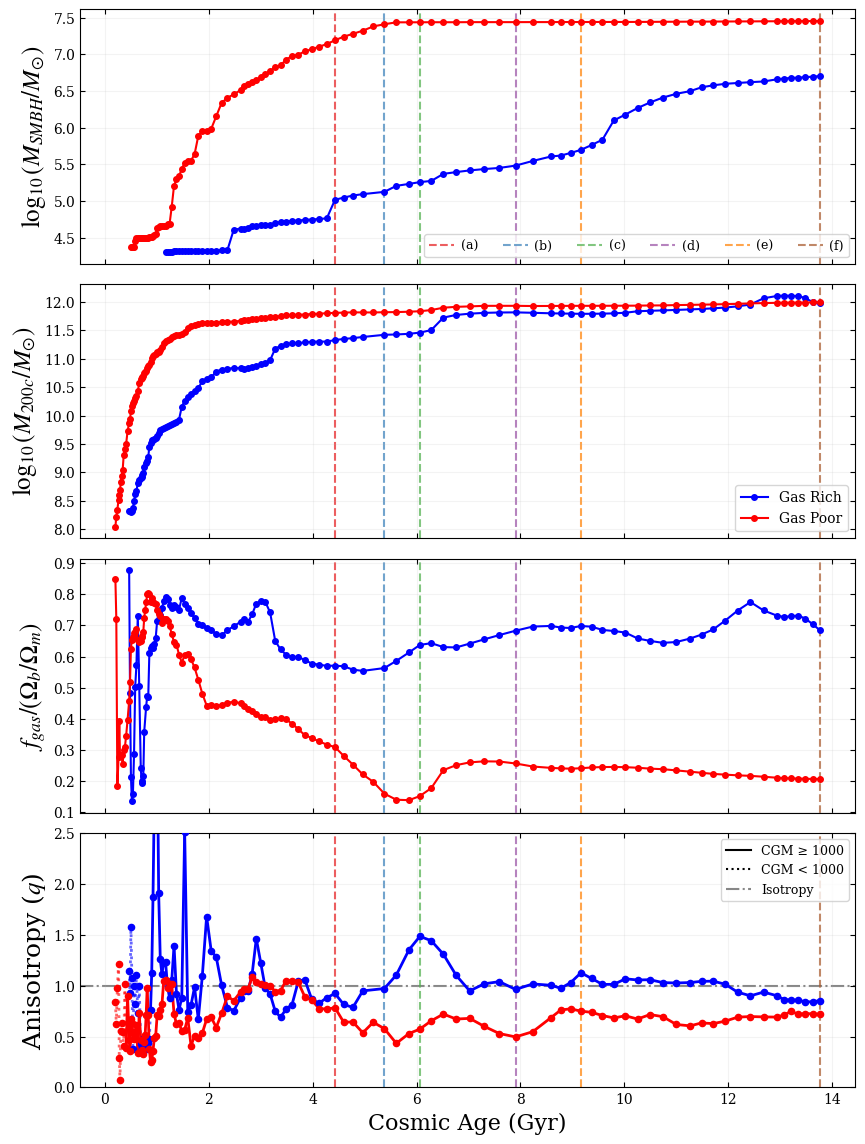

In [ ]:

threshold_value = 1000
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True


fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True, dpi=100)
plt.subplots_adjust(hspace=0.08) 


snapshot_ages = [4.43, 5.38, 6.06, 7.91, 9.16, 13.76]
snapshot_labels = ['a', 'b', 'c', 'd', 'e', 'f']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']


datasets = [
    ('Gas Rich', halo_history_gas_rich, 'blue'),
    ('Gas Poor', halo_history_gas_poor, 'red')
]

ax0, ax1, ax2, ax3 = axes


for label, df, color in datasets:
    
    ax0.plot(df['age_Gyr'], np.log10(df['mmbh_mass']), marker='o', color=color, markersize=4)
     
    ax1.plot(df['age_Gyr'], np.log10(df['mass']), marker='o', color=color, markersize=4, label=label)
    
    ax2.plot(df['age_Gyr'], df['gas_frac']/0.16, marker='o', color=color, markersize=4)

ax0.set_ylabel(r'$\log_{10}(M_{SMBH} / M_{\odot})$', fontsize=18)
ax1.set_ylabel(r'$\log_{10}(M_{200c} / M_{\odot})$', fontsize=18)
ax2.set_ylabel(r'$f_{gas} / (\Omega_{b}/\Omega_{m})$', fontsize=18)


ax1.legend(loc='lower right', fontsize=10, frameon=True)


for label, df, color in datasets:
   
    for i in range(len(df) - 1):
        p1, p2 = df.iloc[i], df.iloc[i+1]
        is_low_res = p2['cgm_gas_count'] < threshold_value
        ls, alpha = (':', 0.6) if is_low_res else ('-', 1.0)
        ax3.plot([p1['age_Gyr'], p2['age_Gyr']], [p1['mass_aniso'], p2['mass_aniso']], 
                 linestyle=ls, color=color, alpha=alpha, linewidth=2)

    
    ax3.scatter(df['age_Gyr'], df['mass_aniso'], color=color, s=20, zorder=5)

ax3.set_ylabel('Anisotropy ($q$)', fontsize=18)
ax3.set_xlabel('Cosmic Age (Gyr)', fontsize=16)
ax3.set_ylim(0, 2.5)

ax3.axhline(y=1, color='dimgray', linestyle='-.', alpha=0.8, zorder=1)


cgm_legends = [
    Line2D([0], [0], color='black', linestyle='-', label=f'CGM ≥ {threshold_value}'),
    Line2D([0], [0], color='black', linestyle=':', label=f'CGM < {threshold_value}'),
    Line2D([0], [0], color='dimgray', linestyle='-.', alpha=0.8, label='Isotropy')
]
ax3.legend(handles=cgm_legends, loc='upper right', fontsize=9, frameon=True)


snapshot_handles = []
for ax in axes:
    ax.grid(True, alpha=0.15)
    for age, col in zip(snapshot_ages, colors):
        line = ax.axvline(x=age, color=col, linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
        if ax == ax0: 
            snapshot_handles.append(line)


ax0.legend(handles=snapshot_handles, labels=[f'({l})' for l in snapshot_labels], 
           loc='lower right', ncol=6, fontsize=9, frameon=True, handletextpad=0.5)

plt.show()